## cost function $J(w,b)$ 

### 1. The Functional Purpose

The cost function is a **mathematical measure of performance**. While a loss function calculates error for one data point, $J(w,b)$ aggregates the error across the **entire training set** of $m$ examples.

* **Low $J$:** The model fits the data well.
* **High $J$:** The model's parameters $(w, b)$ are poorly chosen.

### 2. The Squared Error Logic

The standard formula for linear regression is the **Mean Squared Error (MSE)**:


$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

* **Squaring:** Ensures all errors are positive and disproportionately penalizes larger outliers.
* **$\frac{1}{2m}$:** The $m$ provides an average; the $2$ is a constant that simplifies the math during differentiation (canceling the exponent).

### 3. The Convex Property

$J(w,b)$ is a **convex function** (bowl-shaped). This is logically critical because:

* It has **no local minima**, only one global minimum.
* It guarantees that optimization algorithms like **Gradient Descent** will always have a clear "downhill" path to the most accurate parameters.

---

**Key Insight:** $J(w,b)$ transforms the abstract goal of "learning" into a concrete task of **minimization**.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KeyboardInterrupt: 

In [7]:
# 代价函数
def computeCost(X, Y, theta):
    inner = np.power((X * theta.T) - Y, 2)
    return np.sum(inner) / (2 * len(X))


## Gradient Descent: The Essentials

### 1. The Goal

Minimize the **Cost Function $J(w,b)$** (the error) by iteratively adjusting parameters $w$ and $b$.

### 2. The Update Rule

Go "downhill" by subtracting the gradient from the current value:


$$w = w - \alpha \frac{\partial}{\partial w} J(w,b)$$

$$b = b - \alpha \frac{\partial}{\partial b} J(w,b)$$

* **$\alpha$ (Learning Rate):** Your step size.
* **Small $\alpha$:** Reliable but slow.(baby step)
* **Large $\alpha$:** Fast, but may overshoot(exceeding a intended target, limit, or capacity) or never converge.



### 3. Simultaneous Update

**Crucial:** You must calculate the gradients for both $w$ and $b$ *before* updating either.

* **Correct:** Calculate `tmp_w` and `tmp_b` using the original values, then update.
* **Incorrect:** Updating $w$ first and then using the *new* $w$ to calculate the gradient for $b$. This "warps" the coordinate system mid-step.

### 4. Local vs. Global Minima

* **Convex (Bowl-shaped):** One single bottom point (**Global Minimum**). Found in Linear Regression.
* **Non-Convex:** Many "valleys" (**Local Minima**). The algorithm can get stuck in a sub-optimal spot.

---

**Key Insight:** As you approach the bottom, the gradient $\frac{\partial}{\partial w}$ naturally gets smaller, so your steps automatically shorten even if $\alpha$ stays the same.



### 1. Fixed Learning Rate ($\alpha$) and Convergence
A common misconception is that the learning rate $\alpha$ must be decreased over time to reach a local minimum. In reality, **Gradient Descent can reach a local minimum with a fixed learning rate.**

* **The Mechanism:** As the algorithm approaches the local minimum, the slope (gradient) $\frac{\partial}{\partial w}J(w)$ naturally becomes smaller. 
  
* **The Update Rule:** Since the update is $w := w - \alpha \frac{\partial}{\partial w}J(w)$, a shrinking gradient automatically results in smaller steps, even if $\alpha$ remains constant.
  
* **The Visual:** Imagine walking down a bowl-shaped hill. As the ground levels out near the bottom, your "steps" (which are proportional to the steepness) naturally shorten until you come to a halt at the plateau (where the gradient is zero).



---

### 2. Batch Gradient Descent
In the context of Andrew Ng's course, "Batch" refers to the fact that the algorithm uses **all** training examples in every single step of gradient descent.

#### The Mathematical Definition
For a linear regression model, the simultaneous update for parameters $\theta_j$ is:

$$\theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m} (f_{\theta}(x^{(i)}) - y^{(i)})x_j^{(i)}$$

* **$m$:** The total number of training examples.
* **$\sum_{i=1}^{m}$:** This summation confirms that we look at the entire "batch" of data before making a single adjustment to the weights.

#### Key Characteristics
* **Consistency:** The cost function $J(\theta)$ should decrease after every single iteration if the learning rate is set correctly. This produces a smooth convergence curve.
* **Computational Cost:** For very large datasets (e.g., $m = 1,000,000$), calculating the gradient becomes computationally expensive and slow because you must sum over a million examples just to take one step.
* **Global Minimum:** For convex functions (like Linear Regression), Batch Gradient Descent is guaranteed to converge to the global minimum.

---

### 3. Practical Implementation Tips
To ensure your notes are functional for coding, keep these two logical checks in mind:

1.  **Simultaneous Update:** Always calculate the updates for all parameters ($\theta_0, \theta_1, \dots, \theta_n$) using the *old* values first, then update them all at once. If you update $\theta_0$ and then use the new $\theta_0$ to calculate $\theta_1$, you are no longer doing standard Gradient Descent.
2.  **Feature Scaling:** Gradient Descent converges much faster if features are on a similar scale (e.g., $-1 \le x \le 1$). This prevents the "contour lines" of the cost function from becoming too elongated, which causes the gradient to "oscillate" wildly.




## Multiple Linear Regression

### 1. Model Definition (Multiple Variables)
When we move from one feature to $n$ features, the model expands to account for each input variable $x_j$ with its own weight $w_j$.

For a model with $n=10$ features, the prediction function is:
$$f_{w,b}(x) = w_1 x_1 + w_2 x_2 + w_3 x_3 + \dots + w_{10} x_{10} + b$$

* **$x_j$**: The $j^{th}$ feature.
* **$w_j$**: The weight (parameter) for the $j^{th}$ feature, representing its relative importance to the prediction.
* **$b$**: The bias term (a single number).

---

### 2. Parameters and Vectors
To manage many features efficiently, we group the parameters and features into **vectors**. This is the foundation of modern machine learning implementation.

* **Weight Vector ($\mathbf{w}$):** $\mathbf{w} = [w_1, w_2, \dots, w_n]$
* **Feature Vector ($\mathbf{x}$):** $\mathbf{x} = [x_1, x_2, \dots, x_n]$
* **Bias ($b$):** A scalar value.



---

### 3. Vectorization & The Dot Product
Instead of writing a long summation or using a `for` loop in code (which is slow), we simplify the model using the **dot product**.

**Mathematical Simplification:**
$$f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b$$

**Why use Dot Products?**
1.  **Code Clarity:** It turns dozens of lines of addition into a single operation.
2.  **Computational Efficiency:** Libraries like NumPy (Python) or Eigen (C++) use **parallel processing** in the CPU/GPU to calculate dot products much faster than a standard loop.

---

### 4. Gradient Descent for Multiple Variables
The update rule for Batch Gradient Descent remains conceptually the same, but it now applies to every parameter $w_j$ simultaneously.

For each $j = 1 \dots n$:
$$w_j := w_j - \alpha \frac{1}{m} \sum_{i=1}^{m} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_j^{(i)}$$
$$b := b - \alpha \frac{1}{m} \sum_{i=1}^{m} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})$$

> **Note:** In Batch Gradient Descent, we calculate the error for the entire "batch" (all $m$ examples) before updating the vector $\mathbf{w}$.

---

### 5. Summary Table: Single vs. Multiple Variables

| Feature | Simple Linear Regression | Multiple Linear Regression |
| :--- | :--- | :--- |
| **Variables** | 1 ($x$) | $n$ ($x_1, x_2, \dots, x_n$) |
| **Parameters** | $w, b$ | $\mathbf{w}$ (vector), $b$ (scalar) |
| **Form** | $f = wx + b$ | $f = \mathbf{w} \cdot \mathbf{x} + b$ |



## Module: Vectorization in Machine Learning

### 1. The Core Concept
Vectorization is the process of replacing explicit `for` loops in your code with **array expressions**. In the context of Andrew Ng's course, this refers specifically to calculating the model's prediction and the gradient updates.

* **Non-Vectorized (Slow):** Loops through each feature $j$ one by one to calculate $w_j x_j$.
* **Vectorized (Fast):** Uses a single **dot product** operation to calculate the entire sum at once.

### 2. Implementation with NumPy
Using `np.dot()` allows the computer to utilize **Parallel Computing**. Instead of calculating $w_1x_1$, then $w_2x_2$ sequentially, a modern CPU/GPU can calculate multiple products simultaneously.



#### Code Reference
```python
import numpy as np

# Parameters: w is a vector (1-D array), b is a scalar (number)
w = np.array([2.0, 2.5, -3.3])
b = 4

# Input: x is a feature vector
x = np.array([10, 20, 30])

# Vectorized Calculation: f = w1x1 + w2x2 + w3x3 + b
f = np.dot(w, x) + b

print(f) # Result: -25.0
```

### 3. Why it Matters: The Hardware Level
The reason vectorization is a "must-have" rather than a "nice-to-have" in ML involves two hardware optimizations:
1.  **SIMD (Single Instruction, Multiple Data):** Modern processors have instructions that can perform the same operation (like multiplication) on a batch of data in a single clock cycle.
2.  **Parallelization:** In Batch Gradient Descent, when you have $m=100,000$ examples, vectorization allows the system to distribute the workload across multiple cores.

---

### 4. Mathematical Mapping
When reviewing your notes, remember that the dot product is mathematically equivalent to the summation of products:

$$\mathbf{w} \cdot \mathbf{x} = \sum_{j=1}^{n} w_j x_j = w_1x_1 + w_2x_2 + \dots + w_nx_n$$

> **Crucial Insight:** Vectorization isn't just about "shorter code." It is the difference between a model training in **10 seconds** versus **10 hours** when the dataset is large.


gradient descent to process multiple variables with vectorization
previous vs vector notation 

an alternative to gradient descent
normal equation only for linear regression,solve for w,b whitout iterations, disadvantages:


## Feature Scaling

### 1. The Relationship Between Range and Parameters
In a model where features have vastly different scales (e.g., $x_1$ = house size in sq ft [0–2000], $x_2$ = number of bedrooms [1–5]):
* **Large Range ($x_1$)**: Small changes in $w_1$ lead to huge changes in the prediction. Therefore, the model needs a **small parameter** $w_1$ to compensate.
* **Small Range ($x_2$)**: The model typically needs a **large parameter** $w_2$ to have any meaningful impact on the output.

### 2. Impact on Gradient Descent (The "Oval" Problem)
If features are not scaled, the contour plot of the cost function $J(w, b)$ becomes a **tall, skinny oval** (highly eccentric).

* **The Problem**: Gradient Descent always moves perpendicular to the contour lines. In an oval-shaped cost function, the gradient doesn't point directly toward the center (minimum).
* **The Result**: The optimization may **bounce back and forth** (oscillate) for a long time before reaching the center, making the process extremely slow.



---

### 3. Solution: Feature Rescaling
By rescaling, we transform the contours into **circles**. This allows Gradient Descent to point directly toward the global minimum, leading to a much faster and smoother "straight-line" convergence.

#### Methods to Rescale:
1.  **Divide by Maximum**: 
    $$x_{new} = \frac{x}{max}$$
    Simple, but sensitive to outliers.
2.  **Mean Normalization**: 
    $$x_{i} = \frac{x_i - \mu_i}{max - min}$$
    Centers the data around zero (range usually $-0.5$ to $0.5$).
3.  **Z-score Normalization (Standardization)**: 
    $$x_{i} = \frac{x_i - \mu_i}{\sigma_i}$$
    Uses the mean ($\mu$) and standard deviation ($\sigma$). This is the most robust method for many algorithms.

---

### 4. The Goal Range
The aim is to get each feature $x_i$ into a similar scale, typically:
$$-1 \le x_i \le 1$$
* **Acceptable ranges**: Roughly $-3$ to $+3$ or $-0.3$ to $+0.3$ are usually fine.
* **When to scale**: If a feature is too large (e.g., $-100$ to $100$) or too small (e.g., $-0.0001$ to $0.0001$), rescaling is mandatory for Gradient Descent to function properly.




### Part 1: Diagnosing and Optimizing Gradient Descent

To ensure Gradient Descent is effectively minimizing the cost function $J(\vec{w},b)$, you must monitor its progression. Relying blindly on the algorithm without diagnostics can lead to non-convergence.

**1. The Learning Curve**
*   **What it is:** A plot with the number of iterations on the x-axis and the value of the cost function $J(\vec{w},b)$ on the y-axis.
*   **The Essence:** It visually represents the optimization trajectory. A healthy learning curve should decrease strictly monotonically (going down at every single step) and eventually flatten out (plateau), indicating it has reached a minimum.


**2. Verifying Convergence**
*   **Automatic Convergence Test:** You can set an algorithm to stop when $J(\vec{w},b)$ decreases by less than a very small threshold, $\epsilon$ (e.g., $\epsilon = 10^{-3}$), in a single iteration.
*   **The Reality:** While $\epsilon$ is mathematically convenient, choosing the "right" $\epsilon$ is difficult. In practice, visual inspection of the learning curve is a far more reliable indicator of whether the algorithm has truly converged or is just moving slowly.

**3. Choosing the Learning Rate ($\alpha$)**
*   **The Mathematical Guarantee:** With a *small enough* learning rate, mathematical proofs guarantee that $J(\vec{w},b)$ will decrease on every single iteration. 
*   **The Trade-off:** 
    *   If $\alpha$ is too small: Gradient descent works, but it takes an impractically long time to converge.
    *   If $\alpha$ is too large: The algorithm overshoots the minimum. $J(\vec{w},b)$ may oscillate or even diverge (increase over time).
*   **Debugging Strategy:** If your learning curve goes up, or goes up and down irregularly, your $\alpha$ is almost certainly too large. Drop it significantly to verify the code works, then gradually increase it to find the most efficient rate.

---

### Part 2: Feature Engineering and Polynomial Regression

**1. Feature Engineering**
*   **The Essence:** You are not restricted to the raw data you are given. Feature engineering is the process of using domain knowledge to design new features by transforming or combining existing ones. For example, if you have the `frontage` and `depth` of a plot of land, multiplying them creates a new feature: `area`. This allows a simple linear model to capture complex, interactive relationships.

**2. Polynomial Regression & The Necessity of Feature Scaling**
*   **The Concept:** You can fit non-linear curves to your data by taking standard features and raising them to powers (squaring, cubing, etc.). E.g., $f_{\vec{w},b}(x) = w_1x + w_2x^2 + w_3x^3 + b$.
*   **The Hidden Trap (Why Feature Scaling is Critical here):** If your base feature $x$ (e.g., house size) ranges from 1 to 1,000, then $x^2$ ranges from 1 to 1,000,000, and $x^3$ ranges from 1 to 1,000,000,000. 
*   **The Consequence:** The ranges of your features are now vastly different. The cost function's contour plot will become extremely elongated and narrow. Gradient descent will bounce inefficiently back and forth across this narrow valley. **You must apply Feature Scaling (like Z-score normalization) whenever you use Polynomial Regression.**

---

### Part 3: The Transition to Classification

**1. Binary Classification**
*   **The Concept:** Predicting a discrete, finite set of outcomes. In binary classification, the outcome $y$ can only be 0 (Negative Class) or 1 (Positive Class). Example: 0 = Benign tumor, 1 = Malignant tumor.

**2. Why Linear Regression Fails for Classification**
*   **The Threshold Method:** You might attempt to use Linear Regression by setting a threshold: if the predicted value $f(x) \ge 0.5$, predict $y=1$; if $f(x) < 0.5$, predict $y=0$.
*   **The Outlier Problem:** Linear regression tries to fit a line to *all* data points minimizing the squared error. If you add a single extreme outlier (e.g., a massive, highly malignant tumor far to the right of the graph), the linear regression line gets violently pulled toward that outlier to minimize its large squared error.
*   **The Essence of the Failure:** Because the line tilts toward the outlier, the point where the line crosses the 0.5 threshold shifts dramatically. This shifted **Decision Boundary** will now incorrectly classify perfectly obvious positive cases as negative. Linear regression is too sensitive to extreme values to be reliable for classification.


---

### Part 4: Logistic Regression

To fix the outlier problem, we need an algorithm whose output is strictly bounded between 0 and 1, regardless of how extreme the input $x$ is.

**1. The Sigmoid (Logistic) Function**
*   **The Formula:** 
    $$g(z) = \frac{1}{1 + e^{-z}}$$
*   **The Shape:** It creates an S-shaped curve that asymptotes at 0 and 1. It crosses 0.5 exactly when $z = 0$.
http://googleusercontent.com/image_content/272



**2. Building the Logistic Regression Model**
*   Instead of outputting the linear equation directly, Logistic Regression takes the linear equation and plugs it *inside* the Sigmoid function.
*   Step 1: Calculate the linear output: $z = \vec{w} \cdot \vec{x} + b$
*   Step 2: Apply the Sigmoid function: $f_{\vec{w},b}(\vec{x}) = g(z) = g(\vec{w} \cdot \vec{x} + b)$
*   **Interpretation:** The output $f_{\vec{w},b}(\vec{x})$ is interpreted as a **probability**. If the output is 0.7, the model is stating there is a 70% probability that $y=1$ given the input features $\vec{x}$.

---

### Part 5: The Decision Boundary

**1. The Mathematical Definition**
The decision boundary is the exact line (or hyperplane) that separates the area where we predict $y=1$ from the area where we predict $y=0$.
*   We predict $y=1$ when $g(z) \ge 0.5$.
*   Looking at the Sigmoid function, $g(z) \ge 0.5$ happens strictly when $z \ge 0$.
*   Therefore, since $z = \vec{w} \cdot \vec{x} + b$, the decision boundary is exactly the mathematical set of points where:
    $$\vec{w} \cdot \vec{x} + b = 0$$

**2. Non-Linear Decision Boundaries**
*   **The Essence:** The decision boundary equation $\vec{w} \cdot \vec{x} + b = 0$ is just a line. How do we classify data that cannot be separated by a straight line?
*   **The Solution:** We combine Logistic Regression with **Polynomial Feature Engineering**.
*   By adding higher-order terms (e.g., $x_1^2$, $x_2^2$) into the $z$ equation, our condition becomes something like $w_1x_1^2 + w_2x_2^2 + b = 0$. 
*   This is the mathematical equation for complex geometric shapes. For example, $x_1^2 + x_2^2 - 1 = 0$ creates a circular decision boundary, allowing Logistic Regression to isolate clusters of data surrounded by other data.

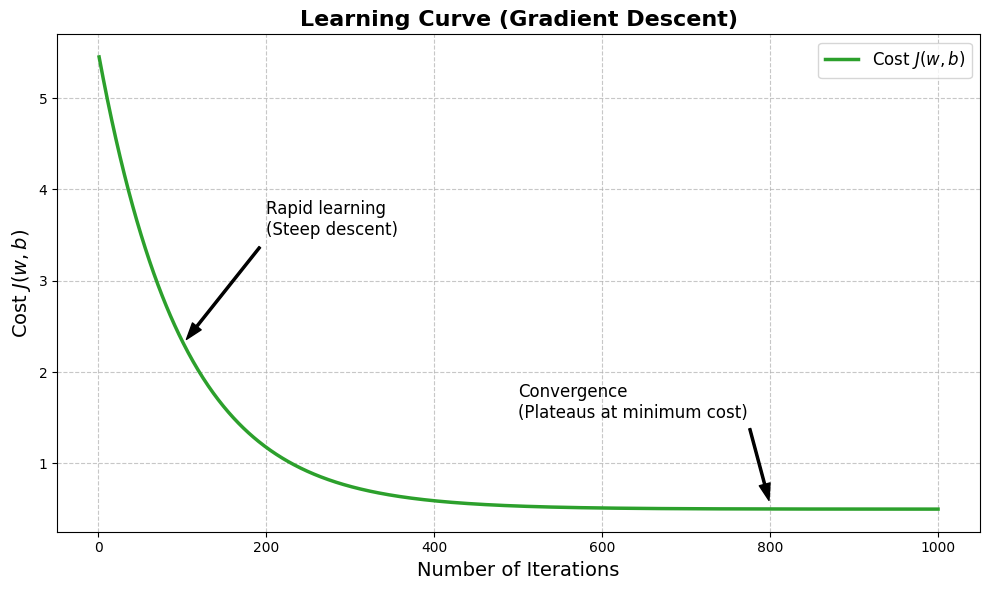

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 模拟迭代次数 (x轴)
# 假设我们进行了 1000 次梯度下降迭代
iterations = np.arange(1, 1001)
# 2. 模拟代价函数 J(w,b) 的下降过程 (y轴)
# 一个健康的梯度下降通常呈现指数衰减的趋势。
# 这里我们用指数函数模拟：随着迭代增加，代价迅速下降，最终逼近一个最小值（这里假设最小代价是 0.5）
cost = 5 * np.exp(-0.01 * iterations) + 0.5

# 3. 设置绘图区域
plt.figure(figsize=(10, 6))

# 4. 绘制学习曲线
plt.plot(iterations, cost, color='#2ca02c', linewidth=2.5, label='Cost $J(w,b)$')

# 5. 添加注释以深入解释曲线的各个阶段

# 阶段一：初始的快速下降
plt.annotate('Rapid learning\n(Steep descent)', xy=(100, 2.3), xytext=(200, 3.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=12)

# 阶段二：收敛并平缓
plt.annotate('Convergence\n(Plateaus at minimum cost)', xy=(800, 0.55), xytext=(500, 1.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=12)

# 6. 设置坐标轴标签、标题和网格
plt.title('Learning Curve (Gradient Descent)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Iterations', fontsize=14)
plt.ylabel('Cost $J(w,b)$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# 7. 优化布局并显示图形
plt.tight_layout()
plt.show()

Matplotlib is building the font cache; this may take a moment.


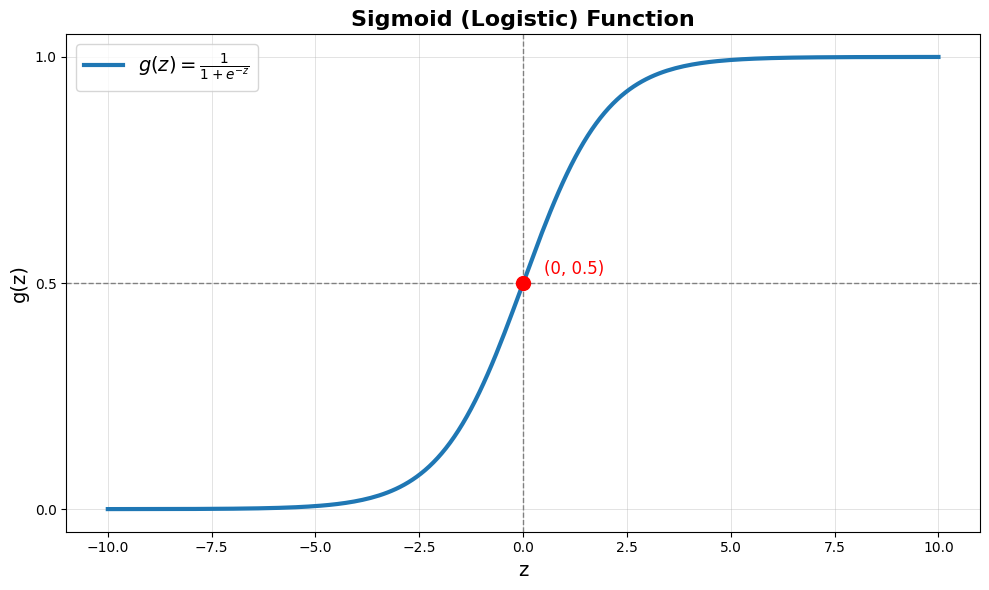

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 定义 Sigmoid (Logistic) 函数
def sigmoid(z):
    """
    计算 sigmoid 函数的值：g(z) = 1 / (1 + e^-z)
    """
    return 1 / (1 + np.exp(-z))

# 2. 生成 z 轴的数据点
# 我们选择从 -10 到 10，这足以清楚地展示 S 形曲线
z = np.linspace(-10, 10, 200)

# 3. 计算对应的 g(z) 值
g_z = sigmoid(z)

# 4. 设置绘图区域
plt.figure(figsize=(10, 6))

# 5. 绘制 Sigmoid 曲线
plt.plot(z, g_z, label=r'$g(z) = \frac{1}{1 + e^{-z}}$', color='#1f77b4', linewidth=3)

# 6. 添加辅助线以增强理解

# 6a. 绘制在 z=0 时的 0.5 水平线，这是逻辑回归的决策阈值
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
# 6b. 绘制垂直线 z=0
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)

# 6c. 标记 (0, 0.5) 这个关键点
plt.scatter(0, 0.5, color='red', s=100, zorder=5) # s 是点的大小
plt.annotate('(0, 0.5)', xy=(0, 0.5), xytext=(0.5, 0.52), fontsize=12, color='red')

# 7. 设置坐标轴标签、标题和网格
plt.title('Sigmoid (Logistic) Function', fontsize=16, fontweight='bold')
plt.xlabel('z', fontsize=14)
plt.ylabel('g(z)', fontsize=14)
plt.grid(True, which='both', linestyle='-', linewidth=0.5, alpha=0.5)

# 8. 设置 y 轴的显示范围，略微超出 0 到 1，以便清楚看到渐近线
plt.ylim(-0.05, 1.05)
plt.yticks([0, 0.5, 1.0]) # 只显示关键刻度

# 9. 添加图例，其中包含数学公式
plt.legend(loc='upper left', fontsize=14)

# 10. 显示图形
plt.tight_layout()
plt.show()

These are excellent notes. Your step-by-step calculus derivation using the Chain Rule is entirely spot-on and shows a deep understanding of the underlying math—something many practitioners gloss over. 

To help you transition from understanding the mechanics to truly mastering the concepts, I have synthesized your raw notes into a comprehensive, structured "Master Note." I've filled in the missing mathematical definitions, added the intuition behind *why* certain phenomena happen, and included the final update rules you will need when you actually program these algorithms.

Here is your complemented Master Note:

***

# Master Note: Logistic Regression, Optimization, and Regularization

## 1. Problem Setup & Notation
* **$m$**: Number of training examples in the dataset.
* **$n$**: Number of features per example.
* **$\vec{x}^{(i)}$**: The feature vector for the $i$-th training example.
* **$y^{(i)}$**: The true target label for the $i$-th example ($y \in \{0, 1\}$).
* **$\vec{w}, b$**: The parameters (weights and bias) of the model.

## 2. The Cost Function (Why Mean Squared Error Fails)
In Linear Regression, we use the Squared Error Cost Function. If we try to use Squared Error for Logistic Regression, plotting the cost against the parameters results in a **non-convex** curve (it looks "wavy" with many local minima). Gradient descent is not guaranteed to find the global minimum here.

### The Solution: Logistic Loss (Binary Cross-Entropy)
Instead, we use a loss function derived from **Maximum Likelihood Estimation (MLE)**. This guarantees a **convex** cost function (a single "bowl" shape), ensuring gradient descent will always converge to the global minimum.

Because $y$ can only be exactly 0 or exactly 1, we can condense the piecewise loss into a single elegant equation:
$$L(f_{\vec{w},b}(\vec{x}), y) = -y \log(f_{\vec{w},b}(\vec{x})) - (1 - y) \log(1 - f_{\vec{w},b}(\vec{x}))$$

The **Total Cost Function** $J(\vec{w}, b)$ is the average of the loss across all $m$ examples:
$$J(\vec{w}, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(f_{\vec{w},b}(\vec{x}^{(i)})) + (1 - y^{(i)}) \log(1 - f_{\vec{w},b}(\vec{x}^{(i)})) \right]$$

## 3. Optimization: Gradient Descent
To find the optimal parameters $\vec{w}$ and $b$, we iteratively update them in the direction of the steepest descent (the negative gradient).

**The Update Rules:**
Repeat until convergence:
$$w_j = w_j - \alpha \frac{\partial}{\partial w_j} J(\vec{w}, b)$$
$$b = b - \alpha \frac{\partial}{\partial b} J(\vec{w}, b)$$
*(Where $\alpha$ is the learning rate).*

*(Reference your excellent Chain Rule derivation here to show that the derivative of the cost function perfectly cancels out the derivative of the sigmoid function).*

The final gradients are:
$$\frac{\partial}{\partial w_j} J(\vec{w}, b) = \frac{1}{m} \sum_{i=1}^m (f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})x_j^{(i)}$$
$$\frac{\partial}{\partial b} J(\vec{w}, b) = \frac{1}{m} \sum_{i=1}^m (f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})$$

**Crucial Insight:** *Why does this look exactly like the Linear Regression gradient?* The equations are structurally identical, but the **hypothesis** $f_{\vec{w},b}(\vec{x})$ is fundamentally different. In linear regression, $f(x) = \vec{w} \cdot \vec{x} + b$. In logistic regression, $f(x) = \sigma(\vec{w} \cdot \vec{x} + b)$. The non-linearity is hidden inside the $f(x)$ term.

### Implementation Enhancements
* **Vectorization:** Instead of using `for` loops across $m$ examples and $n$ features, represent $\vec{X}$ as a matrix and $\vec{w}$ as a vector. Matrix multiplication (using libraries like NumPy) computes predictions and gradients orders of magnitude faster.
* **Feature Scaling (Z-score normalization):** If features are on vastly different scales, the convex "bowl" of the cost function becomes skewed and narrow. Gradient descent will oscillate wildly. Scaling features ensures the contours are circular, allowing for a much faster, direct path to the minimum.

## 4. The Bias-Variance Tradeoff
When training models, we are trying to balance two opposing sources of error:

1.  **Underfitting (High Bias):** The model is too simple. It makes strong, incorrect assumptions (bias) about the data and fails to capture the underlying pattern. It performs poorly on both the training and test sets.
2.  **Generalization (Just Right):** The model captures the true pattern and ignores the noise.
3.  **Overfitting (High Variance):** The model is excessively complex. It fits the training set perfectly—memorizing the exact data points and their random noise. However, slight changes in the data (variance) cause wild changes in the prediction. It fails completely on new, unseen data.

## 5. Addressing Overfitting: Regularization
If your model is overfitting, you have two primary options:
1.  **Feature Selection:** Manually or algorithmically discard features that do not carry enough useful information.
2.  **Regularization:** Keep all the features, but constrain the magnitude of the parameters $w_j$. 

**Intuition:** Large parameter values allow the decision boundary to create sharp, complex curves to encapsulate every single outlier. By forcing the weights to be small, we "smooth out" the decision boundary, making the model more robust to noise.

### The Regularized Cost Function
We add a penalty term to the end of the cost function. $\lambda$ (lambda) is the regularization parameter that balances the goal of fitting the data against the goal of keeping parameters small.
$$J(\vec{w}, b) = \text{Original Cost} + \frac{\lambda}{2m} \sum_{j=1}^{n} w_j^2$$
*(Note: By convention, we do not regularize the bias term $b$, as it only shifts the function left/right and does not contribute to the "wiggliness" of the curve).*

### The Regularized Gradient Descent
Because the cost function changed, the derivative changes slightly. We must add the derivative of the penalty term to the weight update:
$$w_j = w_j - \alpha \left[ \left( \frac{1}{m} \sum_{i=1}^m (f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})x_j^{(i)} \right) + \frac{\lambda}{m} w_j \right]$$

We can algebraically rearrange this to reveal how regularization actually works step-by-step:
$$w_j = w_j \left( 1 - \alpha \frac{\lambda}{m} \right) - \alpha (\text{Original Gradient})$$
Because $(1 - \alpha \frac{\lambda}{m})$ is a number just slightly less than 1, the algorithm literally shrinks the weight by a small percentage on every single iteration before applying the gradient update. This is why this form of regularization is often called **"Weight Decay."**

***
